# SDE simulation in a periodic potential

Simulate 50 independent trajectories of a one-dimensional stochastic differential equation with Diffrax, then plot the paths.

$$
dX_t = -Ak\sin(kX_t)\,dt + \sigma\,dW_t,
\qquad X_0 = 0.
$$

The drift comes from the periodic potential $V(x)=A[1-\cos(kx)]$. Near $x=0$, the drift is approximately $-Ak^2x$, giving a local Ornstein–Uhlenbeck approximation.


## 1. Imports


In [56]:
import diffrax as dfx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt


## 2. Model parameters

$A$ controls the potential amplitude, $k$ sets its spatial period $2\pi/k$, and $\sigma$ is the constant diffusion coefficient. Each trajectory has its own Brownian motion.


In [57]:
A = 1.0
k = 1.0
sigma = 1.1

n_trajectories = 50


## 3. Potential, drift, and diffusion

The deterministic drift points down the potential gradient:

$$
b(x)=-\frac{dV}{dx}=-Ak\sin(kx).
$$

Diffrax expects the drift and diffusion functions to accept `(t, x, args)`.


In [58]:
def V(x):
    """Periodic potential."""
    return A * (1.0 - jnp.cos(k * x))


def drift(t, x, args):
    """Negative gradient of the potential."""
    return -A * k * jnp.sin(k * x)


def diffusion(t, x, args):
    """Constant diffusion coefficient."""
    return sigma


## 4. Time grid and initial condition

`dt` is the solver step size. `ts` contains the 15,000 times at which the solution is saved; its spacing is approximately 0.0333, so it differs from `dt`.


In [59]:
t0 = 0.0
t1 = 500.0
dt = 0.01
x0 = 0.0

ts = jnp.linspace(t0, t1, 15_000)


## 5. Simulate one trajectory

Construct a Brownian path from a random key, combine the drift and diffusion terms, and integrate with the Euler solver. Return the state values at the saved times.


In [60]:
def simulate_one(key):
    """Simulate one trajectory using the supplied random key."""
    brownian = dfx.VirtualBrownianTree(
        t0=t0,
        t1=t1,
        tol=1e-3,
        shape=(),
        key=key,
    )

    terms = dfx.MultiTerm(
        dfx.ODETerm(drift),
        dfx.ControlTerm(diffusion, brownian),
    )

    solution = dfx.diffeqsolve(
        terms,
        dfx.Euler(),
        t0=t0,
        t1=t1,
        dt0=dt,
        y0=x0,
        saveat=dfx.SaveAt(ts=ts),
        max_steps=100_000,
    )
    return solution.ys


## 6. Generate the ensemble

Split the fixed seed into one key per trajectory. `jax.vmap` applies the simulation to all keys. The resulting array has shape `(n_trajectories, len(ts))`, here `(50, 15000)`.


In [61]:
key = jr.PRNGKey(42)
keys = jr.split(key, n_trajectories)

trajectories = jax.vmap(simulate_one)(keys)
print(f"Trajectories shape: {trajectories.shape}")


Trajectories shape: (50, 15000)


## 7. Plot the trajectories

Each line is an independent realization of the same SDE.


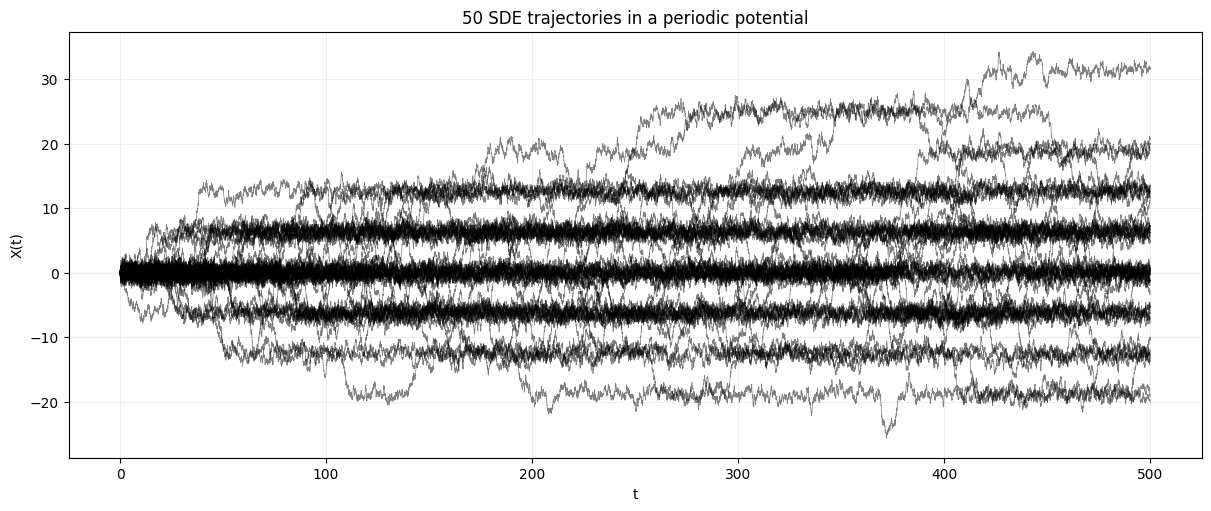

In [62]:
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)

for trajectory in trajectories:
    ax.plot(ts, trajectory, color="black", linewidth=0.5, alpha=0.5)

ax.set(
    xlabel="t",
    ylabel="X(t)",
    title=f"{n_trajectories} SDE trajectories in a periodic potential",
)
ax.grid(alpha=0.2)
plt.show()


## Estimate parameters back via Diffrax

In [64]:
import equinox as eqx
import optax

class NeuralSDE(eqx.Module):
    drift_net: eqx.nn.MLP
    diffusion_net: eqx.nn.MLP

    def __init__(self, key):
        key_b, key_s = jr.split(key)
        self.drift_net = eqx.nn.MLP(
            in_size=1, out_size=1, width_size=64, depth=4,
            activation=jax.nn.tanh, key=key_b,
        )
        self.diffusion_net = eqx.nn.MLP(
            in_size=1, out_size=1, width_size=64, depth=4,
            activation=jax.nn.tanh, key=key_s,
        )

    def b(self, x):
        phase = jnp.asarray([jnp.sin(x), jnp.cos(x)])
        return self.drift_net(phase)[0]

    def s(self, x):
        # A diffusion coefficient must be positive.
        raw = self.diffusion_net(jnp.asarray([x]))[0]
        return jax.nn.softplus(raw) + 1e-3


model = NeuralSDE(jr.PRNGKey(100))

# Each training example is (starting position, increment, elapsed time).
train_paths = trajectories[:40]
x = train_paths[:, :-1].reshape(-1)
dx = jnp.diff(train_paths, axis=1).reshape(-1)
delta = jnp.broadcast_to(
    jnp.diff(ts), train_paths[:, :-1].shape
).reshape(-1)

def loss_fn(model, x_batch, dx_batch, delta_batch):
    b = jax.vmap(model.b)(x_batch)
    s = jax.vmap(model.s)(x_batch)

    # Euler approximation:
    # ΔX | X=x ≈ Normal(b(x)Δt, s(x)^2 Δt)
    residual = dx_batch - b * delta_batch
    return jnp.mean(
        0.5 * residual**2 / (s**2 * delta_batch)
        + jnp.log(s)
    )

optimizer = optax.adam(1e-3)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

@eqx.filter_jit
def train_step(model, opt_state, xb, dxb, dtb):
    loss, grads = eqx.filter_value_and_grad(loss_fn)(
        model, xb, dxb, dtb
    )
    updates, opt_state = optimizer.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

key = jr.PRNGKey(101)
for step in range(1500):
    key, batch_key = jr.split(key)
    indices = jr.randint(batch_key, (2048,), 0, x.size)

    model, opt_state, loss = train_step(
        model, opt_state,
        x[indices], dx[indices], delta[indices],
    )

    if step % 300 == 0:
        print(step, float(loss))

TypeError: dot_general requires contracting dimensions to have the same shape, got (1,) and (2,).

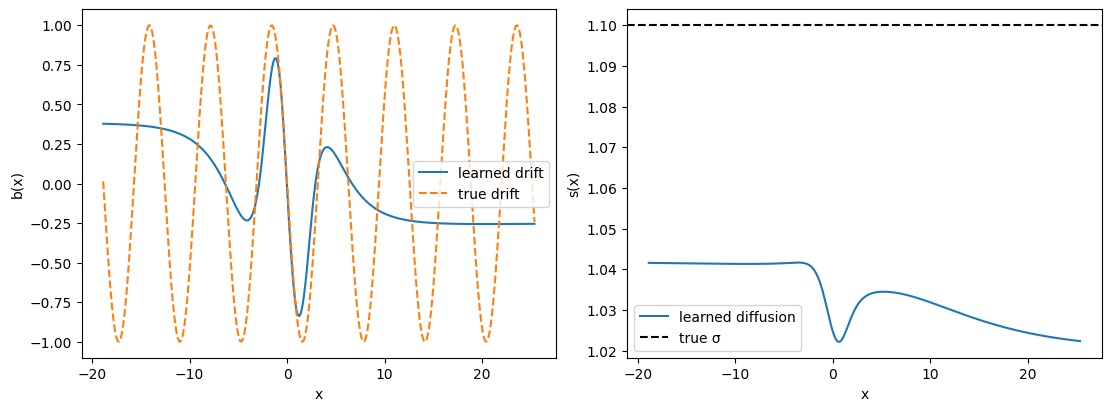

In [ ]:
grid = jnp.linspace(jnp.percentile(x, 1), jnp.percentile(x, 99), 300)
learned_b = jax.vmap(model.b)(grid)
learned_s = jax.vmap(model.s)(grid)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

axes[0].plot(grid, learned_b, label="learned drift")
axes[0].plot(grid, -A * k * jnp.sin(k * grid), "--", label="true drift")
axes[0].legend()
axes[0].set(xlabel="x", ylabel="b(x)")

axes[1].plot(grid, learned_s, label="learned diffusion")
axes[1].axhline(sigma, linestyle="--", color="black", label="true σ")
axes[1].legend()
axes[1].set(xlabel="x", ylabel="s(x)")

plt.show()

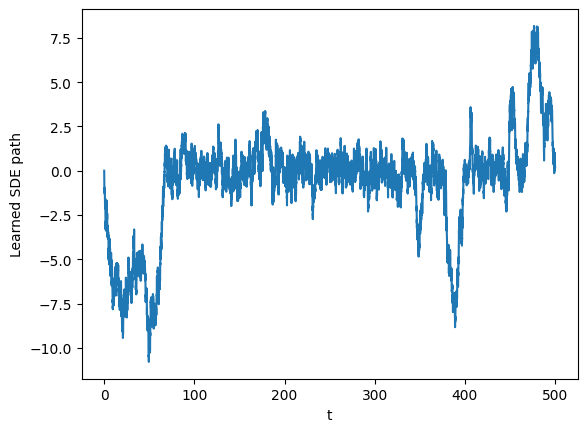

In [ ]:
def learned_drift(t, x, args):
    return model.b(x)

def learned_diffusion(t, x, args):
    return model.s(x)

brownian = dfx.VirtualBrownianTree(
    t0=t0, t1=t1, tol=1e-3, shape=(), key=jr.PRNGKey(202)
)
terms = dfx.MultiTerm(
    dfx.ODETerm(learned_drift),
    dfx.ControlTerm(learned_diffusion, brownian),
)
learned_path = dfx.diffeqsolve(
    terms, dfx.Euler(),
    t0=t0, t1=t1, dt0=dt, y0=x0,
    saveat=dfx.SaveAt(ts=ts),
    max_steps=100_000,
).ys

plt.plot(ts, learned_path)
plt.xlabel("t")
plt.ylabel("Learned SDE path")
plt.show()

In [ ]:
sample_x = x[::100]  # positions from the training data
learned_b = jax.vmap(model.b)(sample_x)
learned_s = jax.vmap(model.s)(sample_x)

k_known = 1.0
basis = -k_known * jnp.sin(k_known * sample_x)

A_hat = jnp.sum(basis * learned_b) / jnp.sum(basis**2)
sigma_hat = jnp.mean(learned_s)

print("A from neural drift:", float(A_hat))
print("sigma from neural diffusion:", float(sigma_hat))

A from neural drift: 0.38928285241127014
sigma from neural diffusion: 1.0324434041976929


In [ ]:
k_known = 1.0
shape = -k_known * jnp.sin(k_known * x)

A_direct = jnp.sum(shape * dx) / jnp.sum(shape**2 * delta)
sigma_direct = jnp.sqrt(
    jnp.mean((dx - A_direct * shape * delta)**2 / delta)
)

print("Direct A:", float(A_direct))
print("Direct sigma:", float(sigma_direct))
print("Neural-derived A:", float(A_hat))
print("Neural-derived sigma:", float(sigma_hat))
print("Position range:", float(x.min()), float(x.max()))

Direct A: 0.9059192538261414
Direct sigma: 1.0360151529312134
Neural-derived A: 0.38928285241127014
Neural-derived sigma: 1.0324434041976929
Position range: -25.68797492980957 34.375587463378906


In [ ]:
probe_x = x[::100]
b_from_net = jax.vmap(model.b)(probe_x)
s_from_net = jax.vmap(model.s)(probe_x)

basis = -k_known * jnp.sin(k_known * probe_x)
A_from_net = jnp.sum(basis * b_from_net) / jnp.sum(basis**2)
sigma_from_net = jnp.mean(s_from_net)

print("Direct: ", float(A_direct), float(sigma_direct))
print("Neural: ", float(A_from_net), float(sigma_from_net))

Direct:  0.9059192538261414 1.0360151529312134
Neural:  0.38928285241127014 1.0324434041976929


In [ ]:
import numpy as np

paths = np.asarray(trajectories)  # shape: (50, 15000)
times = np.asarray(ts)

x = paths[:, :-1]                 # position at the start of each interval
dx = np.diff(paths, axis=1)       # observed change during each interval
delta = np.diff(times)[None, :]   # time between saved observations

k_known = 1.0

# Predicted increment is A * predictor.
predictor = -k_known * np.sin(k_known * x) * delta

# Find the A that best predicts the observed increments.
A_hat = np.sum(predictor * dx) / np.sum(predictor**2)

# What's left after subtracting the predicted drift?
residual = dx - A_hat * predictor

# Residual / sqrt(delta) should have standard deviation sigma.
sigma_hat = np.sqrt(np.mean(residual**2 / delta))

print(f"Estimated A:     {A_hat:.4f}  (simulated value: 1.0)")
print(f"Estimated sigma: {sigma_hat:.4f}  (simulated value: 1.1)")

Estimated A:     0.9063  (simulated value: 1.0)
Estimated sigma: 1.0359  (simulated value: 1.1)
